# Finance comment analysis using NLP

Description of project goes here

In [61]:
## Necessary Libraries
import os

## Hugging face dataset library
from datasets import load_dataset, Dataset

## Manipulating data
import numpy as np
import pandas as pd

## String manipulation
import re

## nltk
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

## Tokenization
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

## sklearn
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

## Pytorch
import torch

## Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

## Setting the plot style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 11

## Seed
np.random.seed(26)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/rishabh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## EDA

### Loading data and basic analysis

Load the twitter financial news sentiment dataset from huggingface hub
> Note: sentiments = {
    "LABEL_0": "Bearish", 
    "LABEL_1": "Bullish", 
    "LABEL_2": "Neutral"
}  

In [2]:
dataset = load_dataset("zeroshot/twitter-financial-news-sentiment")

In [3]:
## size of train, validation set

print(f"Shape of the training dataset : {dataset["train"].shape}")
print(f"Shape of the validation dataset : {dataset["validation"].shape}")

Shape of the training dataset : (9543, 2)
Shape of the validation dataset : (2388, 2)


The training dataset has two columns corresponding to text and label and 9,543 rows, whereas the validation dataset has 2,388 rows.

In [4]:
## convert to pandas dataframe for easy analysis

df_train = dataset["train"].to_pandas()
df_val = dataset["validation"].to_pandas()

In [5]:
## Column names and datatype

df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    9543 non-null   str  
 1   label   9543 non-null   int64
dtypes: int64(1), str(1)
memory usage: 954.7 KB


In [6]:
## Check for missing values

df_train.isna().mean()

text     0.0
label    0.0
dtype: float64

There is no missing value or Nan in the training data.

In [7]:
## Looking at validation data for ensuring similar structure to the train data

df_val.info()

df_val.isna().mean()

<class 'pandas.DataFrame'>
RangeIndex: 2388 entries, 0 to 2387
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    2388 non-null   str  
 1   label   2388 non-null   int64
dtypes: int64(1), str(1)
memory usage: 241.4 KB


text     0.0
label    0.0
dtype: float64

In [8]:
## defining label mapping
label_map = {
    0: "Bearish", 
    1: "Bullish", 
    2: "Neutral"
}

### Label analysis and class imbalance

In [9]:
## Looking at class imbalance in each dataset

print(f"Class distribution in training dataset:\n{df_train["label"].value_counts(normalize = True)}")
print(f"Class distribution in validation dataset:\n{df_val["label"].value_counts(normalize = True)}")

Class distribution in training dataset:
label
2    0.647386
1    0.201509
0    0.151106
Name: proportion, dtype: float64
Class distribution in validation dataset:
label
2    0.655779
1    0.198911
0    0.145310
Name: proportion, dtype: float64


Significant class imbalance: Neutral dominates at 64.7%, Bearish is the minority class at 15.1%. Will use weighted F1 as primary evaluation metric and apply class weights during training.

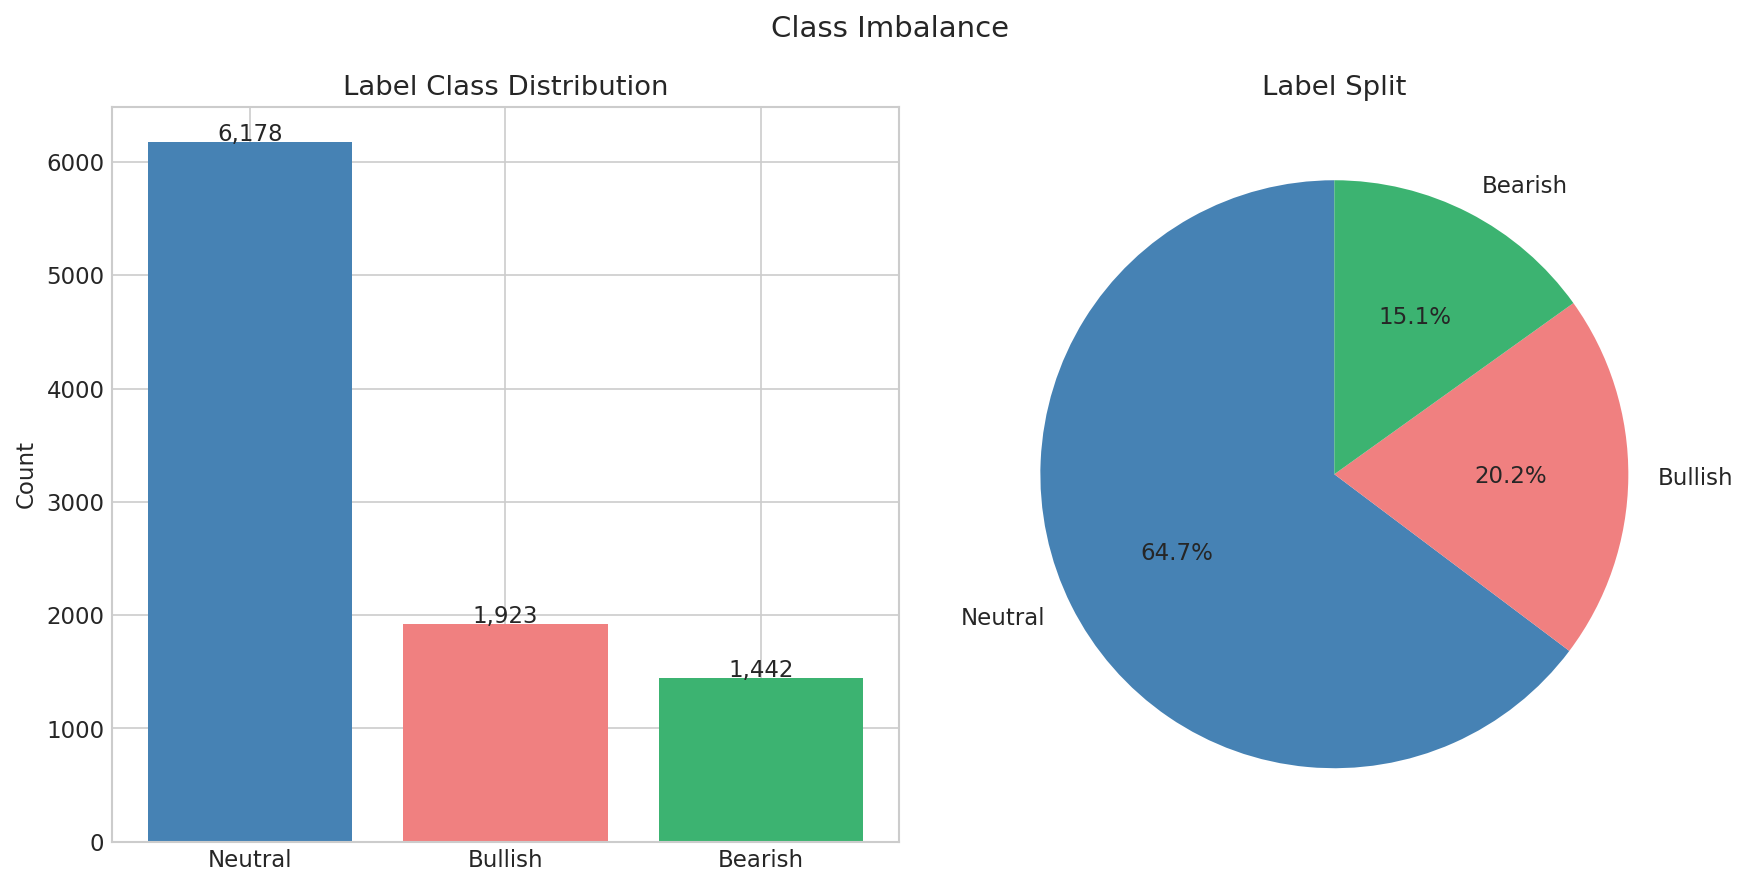

In [10]:
## Class imbalance plot

label_counts = df_train["label"].value_counts()
labels = [label_map[2], label_map[1], label_map[0]]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Bar chart
axes[0].bar(labels, label_counts.values, color=["steelblue", "lightcoral", "Mediumseagreen"])
axes[0].set_title("Label Class Distribution")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0,1,2])
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 10, f"{v:,}", ha="center")

# Pie chart
axes[1].pie(label_counts.values, labels=labels, colors=["steelblue", "lightcoral", "Mediumseagreen"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Label Split")

plt.suptitle("Class Imbalance", fontsize=14)
plt.tight_layout()
plt.savefig("Report/figures/class_imbalance.png",bbox_inches="tight")
plt.show()

### Text statistics

In [11]:
## Distribution of character and words

## Character distribution
print(f"Character distribution in the training set:\n{df_train["text"].str.len().describe()}")

## Word distribution
print(f"\nWord distribution in the training set:\n{df_train["text"].str.split().str.len().describe()}")

Character distribution in the training set:
count    9543.000000
mean       85.816934
std        35.097229
min         2.000000
25%        58.000000
50%        79.000000
75%       120.000000
max       190.000000
Name: text, dtype: float64

Word distribution in the training set:
count    9543.000000
mean       12.178351
std         4.665599
min         1.000000
25%         9.000000
50%        11.000000
75%        15.000000
max        32.000000
Name: text, dtype: float64


In [12]:
## Character distribution by class

df_train.groupby("label")["text"].apply(lambda x: x.str.split().str.len().describe())

label       
0      count    1442.000000
       mean       12.000693
       std         4.306846
       min         3.000000
       25%         9.000000
       50%        11.000000
       75%        15.000000
       max        32.000000
1      count    1923.000000
       mean       11.926157
       std         4.317975
       min         2.000000
       25%         9.000000
       50%        11.000000
       75%        14.000000
       max        29.000000
2      count    6178.000000
       mean       12.298317
       std         4.843131
       min         1.000000
       25%         9.000000
       50%        12.000000
       75%        16.000000
       max        29.000000
Name: text, dtype: float64

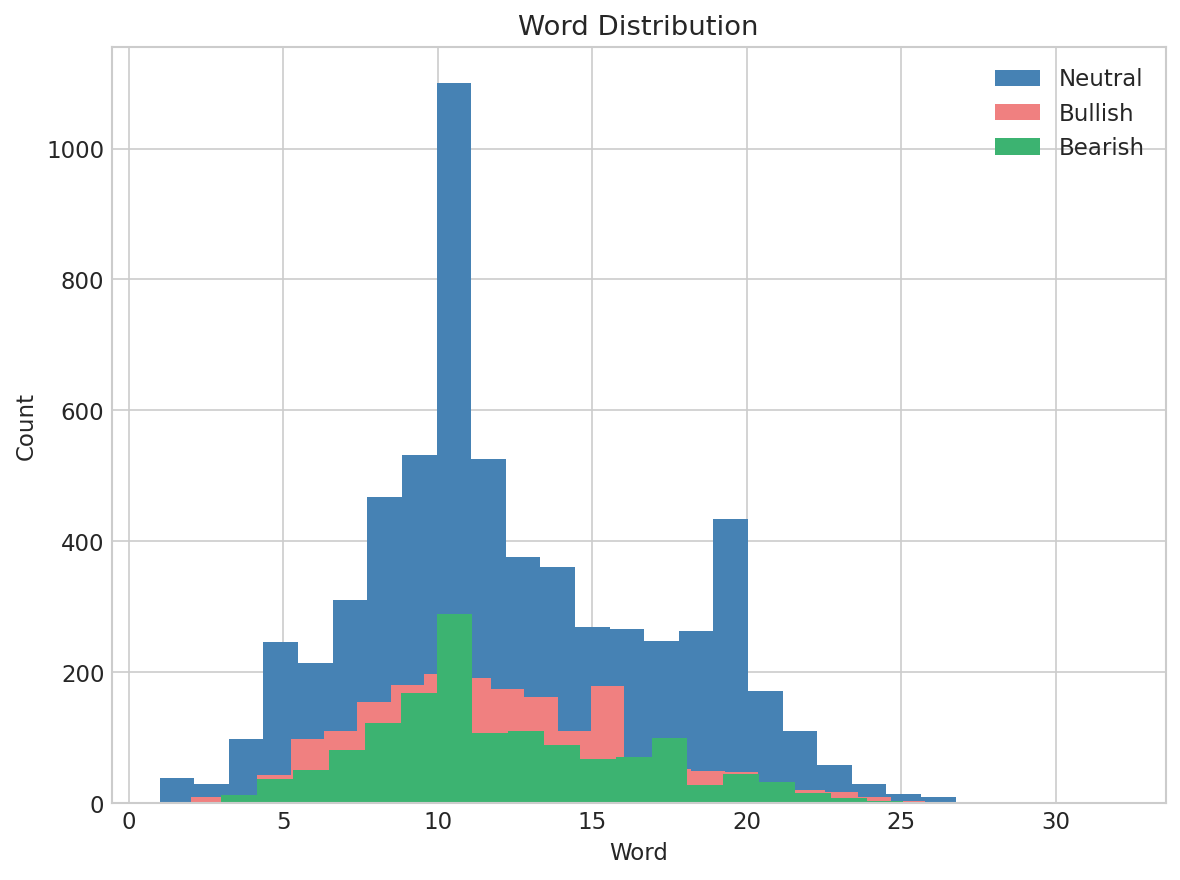

In [13]:
## Word Distribution plot

plt.figure(figsize=(8, 6))

# TransactionAmt distribution - fraud vs normal
neutral = df_train[df_train["label"] == 2]["text"].str.split().str.len()
bearish = df_train[df_train["label"] == 0]["text"].str.split().str.len()
bullish = df_train[df_train["label"] == 1]["text"].str.split().str.len()
plt.hist(neutral, bins=25, alpha=1.0, label="Neutral", color="steelblue")
plt.hist(bullish, bins=25, alpha=1.0, label="Bullish", color="lightcoral")
plt.hist(bearish, bins=25, alpha=1.0, label="Bearish", color="Mediumseagreen")
plt.title("Word Distribution")
plt.xlabel("Word")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.savefig("Report/figures/word_distribution.png",bbox_inches="tight")
plt.show()

Text length is highly consistent across all three classes, with a mean of approximately 12 words per tweet for Bearish, Bullish, and Neutral respectively. The maximum length across all classes is 32 words, which is well within DistilBERT's 512 token limit, truncation will not be an issue, and __max_length=64__ will be sufficient for tokenization. Since length is nearly identical across classes, sentiment is not expressed through text length but purely through lexical content. One notable observation is a spike at exactly 20 words in the Neutral class, which may indicate a data artifact such as tweets being truncated at a fixed character or word limit.

### Text quality inspection

In [14]:
## Label example inspection

np.random.seed(26)
index_list = np.random.randint(0,100,10)

In [15]:
## Label 0 text inspection

df_0 = df_train[df_train["label"]==0]["text"]
print("Label 0 example:")
for i in index_list:
    print(df_0.iloc[i])

Label 0 example:
Cinedigm Corp. Analysts Are Cutting Their Estimates: Here's What You Need To Know
Earnings Update: electroCore, Inc. Just Reported And Analysts Are Trimming Their Forecasts
$GM - GM loses a bull https://t.co/tdUfG5HbXy
Bluebird bio stock price target cut to $86 from $172 at Evercore ISI
Forescout downgraded to neutral from buy at Monness Crespi Hardt
Lyft stock price target cut to $58 from $70 at Deutsche Bank
Intelsat lower after Morgan Stanley target cut
Napco Security stock price target cut to $30 from $35 at Imperial Capital
American Software downgraded to neutral from buy at B. Riley FBR
Funko stock price target cut to $10 from $25 at Stifel Nicolaus


In [16]:
## Label 1 text inspection

df_1 = df_train[df_train["label"]==1]["text"]
print("Label 1 example:")
for i in index_list:
    print(df_1.iloc[i])

Label 1 example:
Applied Industrial Technologies stock price target raised to $70 from $65 at KeyBanc Capital
Baird likes drug wholesalers in premarket analyst action
$EBAY - Guggenheim sees favorable catalysts for eBay https://t.co/1adfDkHeaw
Analyst: AT&T Is The Top Telecom Pick For 2020
Bank of America stock price target raised to $49 from $48 at Oppenheimer
Canada Goose upgraded to outperform from neutral at Baird, price target C$53
BofA Upgrades WestRock After Containerboard Conference, London Pulp Week
Citi reels in PT on Nu Skin
$TENB - Cowen sees upside in TENB's Indegy purchase https://t.co/Ve7bTreR7Y
Bed Bath & Beyond reiterated as buy at BofA Merrill Lynch


In [17]:
## Label 2 text inspection

df_2 = df_train[df_train["label"]==2]["text"]
print("Label 2 example:")
for i in index_list:
    print(df_2.iloc[i])

Label 2 example:
ECB makes it easier for banks to tap credit amid coronavirus crisis https://t.co/aUORNC7SON https://t.co/rrzy3Yv56J
Italy announces guarantees for bank loans worth over 400 billion euros https://t.co/xmvuhapL8v https://t.co/lOpNKjwNeJ
Benzinga's Top Upgrades, Downgrades For November 25, 2019
Australia central bank pumps liquidity, proposes bond buys to ease financial conditions https://t.co/JkbAPjX6Yv https://t.co/GFYiDHmP2U
Mexico's central bank cuts interest rates to three-year low https://t.co/0N0vaHBnQj
A Rate Cut From Russia?
"the Committee directs the Desk to continue purchasing Treasury bills at least into the second quarter of 2020 to m… https://t.co/b1GHWeY0dy
Bank of Canada’s Poloz Sees Era of Low Global Interest Rates
Twilio Inc. Full-Year Results Just Came Out: Here's What Analysts Are Forecasting For Next Year
SNB's sight deposit holdings rise by second-highest level in 12 months https://t.co/aUsTEz08h3 https://t.co/rMaW0F4suE


Manual inspection of text examples across all three classes reveals that the Twitter Financial News dataset consists of clean, formal financial news language: primarily analyst actions, price target changes, upgrades and downgrades. The text is well structured with minimal noise.

The key preprocessing requirements identified are: URL removal (https://t.co/... links appear frequently, particularly in the Neutral class), and ticker symbol handling ( \\$GM, \\$EBAY, \\$TENB, the \\$ prefix should be stripped while retaining the ticker text as it carries semantic meaning).

Numbers and price figures should be retained as they carry clear sentiment signal: a price target cut from \\$172 to \\$86 is inherently bearish information. 

Notably, there are no emojis, hashtags, or slang present, confirming this is a clean formal dataset. This stands in sharp contrast to what we expect from the WallStreetBets dataset, and is the core motivation for the domain transfer experiment: the model trained on this formal financial language will need to generalize to a completely different linguistic register when evaluated on noisy retail investor text.

Preprocessing steps:

1. Lowercase the text
2. Remove URLs
3. Strip $ from ticker symbols, keep the word
4. Remove extra whitespace

## Preprocessing

In [18]:
def clean_text(text: str)-> str:
    """Clean raw tweet text by lowercasing, removing URLs, stripping ticker symbols of their dollar sign prefix, and normalizing whitespace."""
    text = text.lower()
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'\$([A-Za-z]+)', r'\1', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    
    return text
    

In [19]:
## Preprocessing the train and val dataset

df_train["text"] = df_train["text"].apply(clean_text)
df_val["text"] = df_val["text"].apply(clean_text)

#### Word cloud for each class

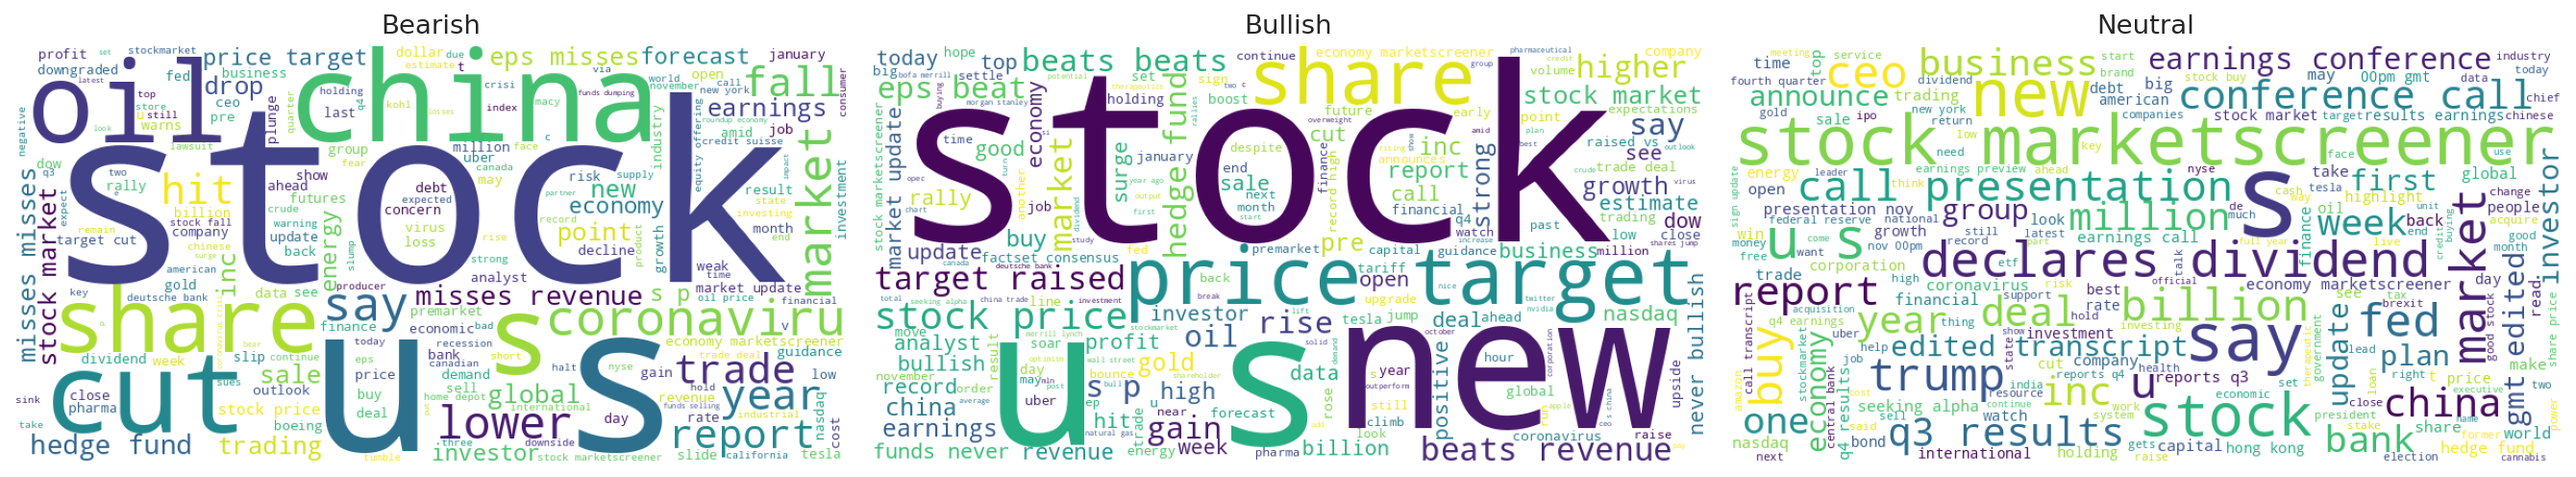

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
labels = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}

for ax, (label, name) in zip(axes, labels.items()):
    
    text = ' '.join(df_train[df_train['label'] == label]['text'])
    
    words = [word for word in text.split() if word not in stop_words]
    text_clean = ' '.join(words)
    
    # Generate wordcloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_clean)
    
    ax.imshow(wordcloud)
    ax.axis('off')
    ax.set_title(name)

plt.tight_layout()
plt.savefig("Report/figures/word_cloud.png",bbox_inches="tight")
plt.show()

The word clouds confirm strong class-separable vocabulary: the model should be able to learn clear lexical signals for Bearish and Bullish. Neutral is harder as it contains mixed financial terminology without directional words.

## Tokenization

In [40]:
## Convert the pandas dataframe back to huggingface dataset

train_dataset = Dataset.from_pandas(df_train)
val_dataset = Dataset.from_pandas(df_val)

In [42]:
## Load tokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

## max length
Max_Length = 64

def tokenize(example: dict) -> dict:
    """Tokenize a single example using DistilBERT tokenizer with padding and truncation."""
    return tokenizer(
        example['text'],
        max_length=Max_Length,
        padding='max_length',
        truncation=True
    )

# Apply to datasets
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

# Set format for PyTorch
train_dataset = train_dataset.rename_column('label', 'labels')
val_dataset = val_dataset.rename_column('label', 'labels')
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

Map:   0%|          | 0/9543 [00:00<?, ? examples/s]

Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

In [43]:
## Checking an example

print(train_dataset[0])

{'labels': tensor(0), 'input_ids': tensor([  101,  2011,  4859,  1011, 16545,  5302, 16998, 15934,  2015,  1999,
        10908,  2006,  3458,  6240,   102,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}


## Training

In [44]:
## Checking if cuda is avialable

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce GTX 1650


In [45]:
## Initialize the model

model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [46]:
## Define class weights

class_weights = compute_class_weight(class_weight='balanced',classes=np.array([0, 1, 2]),y=df_train['label'].values)
class_weights = torch.tensor(class_weights, dtype=torch.float).to('cuda')

In [47]:
## Define custom trainer to deal with class imbalance

class WeightedTrainer(Trainer):
    """Custom Trainer that applies class weights to the loss function to handle class imbalance."""
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """Compute weighted cross entropy loss."""
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss = torch.nn.CrossEntropyLoss(weight=class_weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [48]:
## Define metrics to evaluate model

def compute_metrics(eval_pred) -> dict:
    """Compute weighted F1 and accuracy for evaluation."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'f1_weighted': f1_score(labels, predictions, average='weighted'),
        'accuracy': accuracy_score(labels, predictions)
    }

In [49]:
## Setting up training arguments

training_args = TrainingArguments(
    output_dir='./Report/results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    fp16=True,
    logging_dir='./logs',
    logging_steps=50,
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [50]:
## Initialize the trainer

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

In [51]:
## training

trainer.train()

Epoch,Training Loss,Validation Loss,F1 Weighted,Accuracy
1,0.552808,0.498980,0.814275,0.806533
2,0.307685,0.381070,0.870286,0.867253
3,0.214259,0.394687,0.874670,0.872697


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1791, training_loss=0.4133080701332795, metrics={'train_runtime': 1403.3048, 'train_samples_per_second': 20.401, 'train_steps_per_second': 1.276, 'total_flos': 474059598544512.0, 'train_loss': 0.4133080701332795, 'epoch': 3.0})

Model converges well, achieving 0.875 weighted F1 on the validation set after 3 epochs. Slight divergence between training and validation loss at epoch 3 suggests the model is at the edge of overfitting, 3 epochs is the right stopping point for this dataset size.

In [52]:
## get predictions on val set (for now) 
predictions = trainer.predict(val_dataset)

In [60]:
## Extract labels and pred

logits = predictions.predictions
predicted_class = np.argmax(logits, axis =-1)
true_label = predictions.label_ids

In [62]:
## classification report

y_pred = predicted_class
y_true = true_label
print(classification_report(y_true, y_pred, target_names=['Bearish', 'Bullish', 'Neutral']))

              precision    recall  f1-score   support

     Bearish       0.74      0.85      0.79       347
     Bullish       0.80      0.85      0.82       475
     Neutral       0.94      0.88      0.91      1566

    accuracy                           0.87      2388
   macro avg       0.82      0.86      0.84      2388
weighted avg       0.88      0.87      0.87      2388



<Axes: >

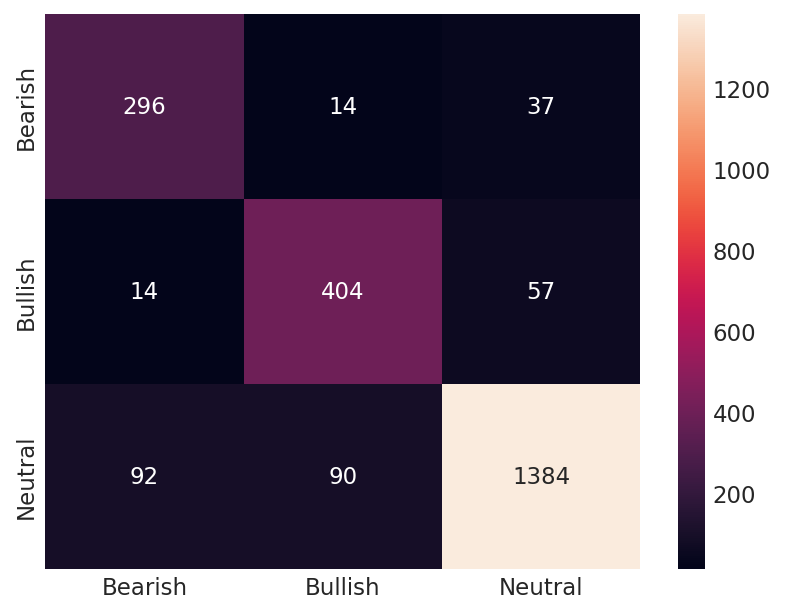

In [64]:
## Confusion matrix

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Bearish', 'Bullish', 'Neutral'], 
            yticklabels=['Bearish', 'Bullish', 'Neutral'])

The model achieves strong in-domain performance with a weighted F1 of 0.87. Neutral is the best performing class (F1 0.91) reflecting its dominance in training data. Bearish is the weakest class (F1 0.79) despite class weighting, showing that minority class performance remains challenging. The high Bearish recall (0.85) suggests class weights successfully prevented the model from ignoring the minority class, at the cost of some precision.

## Testing on WSB dataset

In [66]:
WSB_ds = load_dataset("zchengc/wsb")

In [67]:
WSB_ds

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'title', 'label'],
        num_rows: 1200
    })
    validation: Dataset({
        features: ['Unnamed: 0', 'title', 'label'],
        num_rows: 202
    })
    test: Dataset({
        features: ['Unnamed: 0', 'title', 'label'],
        num_rows: 200
    })
})

In [69]:

df1 = WSB_ds["train"].to_pandas()
df2 = WSB_ds["validation"].to_pandas()
df3 = WSB_ds["test"].to_pandas()

In [70]:
df = pd.concat([df1, df2, df3], ignore_index=True)

In [72]:
df = df.drop(columns = ["Unnamed: 0"])

In [76]:
df = df.rename(columns={"title": "text", "label": "labels"})

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1602 entries, 0 to 1601
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    1602 non-null   str  
 1   labels  1602 non-null   int64
dtypes: int64(1), str(1)
memory usage: 100.3 KB


In [84]:
df.isna().mean()

text      0.0
labels    0.0
dtype: float64

In [85]:
df["labels"].value_counts(normalize = True)

labels
2    0.405119
0    0.366417
1    0.228464
Name: proportion, dtype: float64

In [87]:

df_0 = df[df["labels"]==0]["text"]
print("Label 0 example:")
for i in index_list:
    print(df_0.iloc[i])

Label 0 example:
CHGG to the moon
22 year old college student about to get all the wives!
Just make money.. it’s not that hard
Perfect time to revisit this meme
help me lose my money
I'm not full retarded yet, help!
Don't Forget to Inverse! Puts on Pltr
TSLA to the MOOOOON 🚀🚀🚀🚀
The Best Options Discord Group!
PLTR - here's your chance to buy more you 'tards


In [88]:

df_1 = df[df["labels"]==1]["text"]
print("Label 1 example:")
for i in index_list:
    print(df_1.iloc[i])

Label 1 example:
You can really see when I started getting into options here... at least im autistic now :)
Tell me I’m retarded
Well, that’ll be my first and last attempt at an option
My broker gave me a fucking heartattack showing old sell price.
He bought? dömp it
700c down 69%. Nice
Everything is down today lol
Fucking hell
Gay bears are losing their minds.(Out front of bull headquarters)
I know you’re on here retard, I’m stealing your girlfriend from Etsy. GG


In [89]:

df_2 = df[df["labels"]==2]["text"]
print("Label 2 example:")
for i in index_list:
    print(df_2.iloc[i])

Label 2 example:
My chart has fingers
Apple or Tesla
The top 5 biggest bargains right now
So who is daddy? is it elon or jerome?
Stonks go up immediately if you buy at a high price
Help me pick
Bought 9/4 ZM 400C right before close - how much are these going to be worth in the morning?
I think I saw JPOW at the grocery store (not a copypasta)
I got my dad into day trading and he sends me this.
PD $35c for 9/18


In [93]:
Label_dict = {0:"Bullish",1:"Bearish",2:"Neutral"}

In [91]:
label_remap = {0: 1, 1: 0, 2: 2}
df['labels'] = df['labels'].map(label_remap)

In [92]:
df["labels"].value_counts(normalize = True)

labels
2    0.405119
1    0.366417
0    0.228464
Name: proportion, dtype: float64

In [95]:
df["text"] = df["text"].apply(clean_text)

In [96]:
df["text"]

0                          nice luckin coffee pop today!!
1       amd $90c fds open interest up almost %100 this...
2       5000%!!! yoloed $14k on tsla calls and daddy e...
3                                       thank you, elon!!
4                                       stocks only go up
                              ...                        
1597    if we get enough signatures they can stop all ...
1598                    is it still too late to buy gme??
1599                                           am i wrong
1600      useful strategy that could throw off brokerages
1601                               moving stocks question
Name: text, Length: 1602, dtype: str

In [97]:
## Load tokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

dataset = Dataset.from_pandas(df)
## max length
Max_Length = 64

def tokenize(example: dict) -> dict:
    """Tokenize a single example using DistilBERT tokenizer with padding and truncation."""
    return tokenizer(
        example['text'],
        max_length=Max_Length,
        padding='max_length',
        truncation=True
    )

# Apply to datasets
dataset = dataset.map(tokenize, batched=True)

# Set format for PyTorch
dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

Map:   0%|          | 0/1602 [00:00<?, ? examples/s]

In [98]:
dataset

Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1602
})

In [99]:
predictions = trainer.predict(dataset)

In [100]:

logits = predictions.predictions
predicted_class = np.argmax(logits, axis =-1)
true_label = predictions.label_ids
## classification report

y_pred = predicted_class
y_true = true_label
print(classification_report(y_true, y_pred, target_names=['Bearish', 'Bullish', 'Neutral']))

              precision    recall  f1-score   support

     Bearish       0.70      0.10      0.17       366
     Bullish       0.76      0.18      0.29       587
     Neutral       0.44      0.95      0.60       649

    accuracy                           0.47      1602
   macro avg       0.63      0.41      0.35      1602
weighted avg       0.62      0.47      0.39      1602



<Axes: >

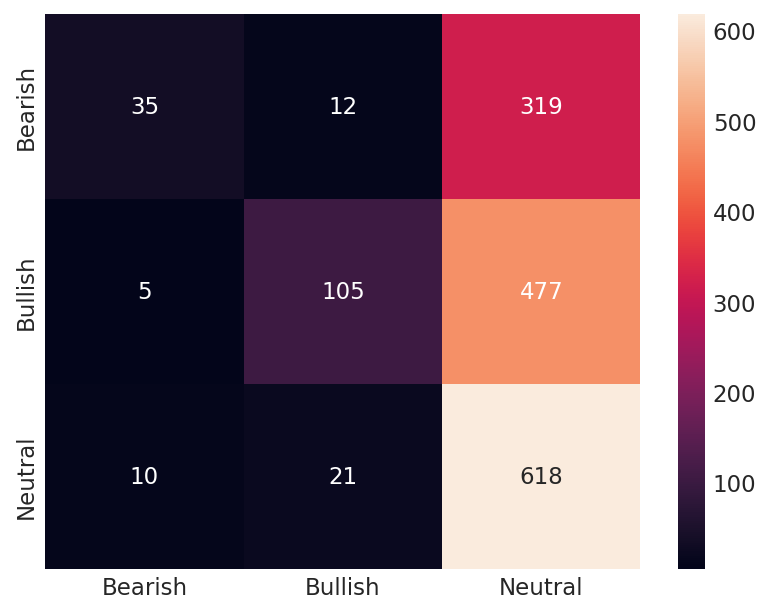

In [101]:
## Confusion matrix

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Bearish', 'Bullish', 'Neutral'], 
            yticklabels=['Bearish', 'Bullish', 'Neutral'])

In [103]:
df[df["labels"]==0]["text"]

238                    gay bear mods lost you all tendies
239     has anybody ever seen td drop the ball this ha...
240                                      why risk it all?
241     i was restricted from robinhood so i deposited...
242     don’t drink &amp; trade fellas. it was meant t...
                              ...                        
1593                                 too late to buy gme?
1594                           is it too late to buy gme?
1597    if we get enough signatures they can stop all ...
1598                    is it still too late to buy gme??
1599                                           am i wrong
Name: text, Length: 366, dtype: str